# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [8]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below

Piotr Makoś

In [9]:
from  sklearn.model_selection import train_test_split
seed = 31287

In [10]:
data = pd.read_csv('data/banknotes_data.csv')

In [11]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [12]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [14]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [15]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [16]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

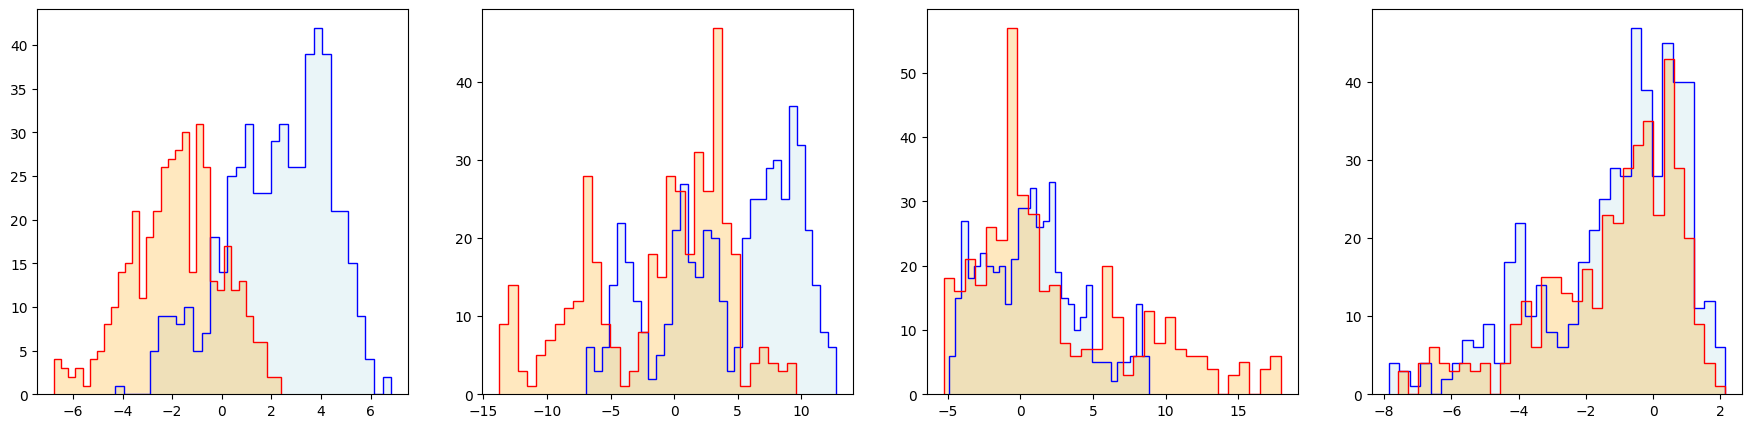

In [17]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

## Problem 2

Using the GaussianNB function construct the Gaussian Bayes classifier using two features. Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot. Additionally, on the test set, compare ROC curve obtained with this 2-features classifier and  1-features classifier (the one from Problem 1, previous classes). What is the improvement of AUC score on the test set when we use 2-features classifier instead of 1-features classifier?

In [18]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, roc_curve

target = 'counterfeit'

features_a0 = ['a0']
features_a0a1 = ['a0', 'a1']
features_all = ['a0', 'a1', 'a2', 'a3']

data_train_fit, data_valid = train_test_split(
    data_train,
    test_size=0.25,
    shuffle=True,
    stratify=data_train[target],
    random_state=seed
)

y_train = data_train_fit[target]
y_valid = data_valid[target]
y_test = data_test[target]

In [19]:
gnb_a0 = GaussianNB()

gnb_a0.fit(data_train_fit[features_a0], y_train)

y_score_test_a0 = gnb_a0.predict_proba(data_test[features_a0])[:, 1]

fprs_test_a0, tprs_test_a0, thresholds_test_a0 = roc_curve(
    y_test,
    y_score_test_a0
)

auc_test_a0 = roc_auc_score(
    y_test,
    y_score_test_a0
)

print(f"Test ROC AUC for 1-feature classifier using a0: {auc_test_a0:.4f}")

Test ROC AUC for 1-feature classifier using a0: 0.9443


In [20]:
gnb_a0a1 = GaussianNB()

gnb_a0a1.fit(data_train_fit[features_a0a1], y_train)

y_pred_train_a0a1 = gnb_a0a1.predict(data_train_fit[features_a0a1])
y_pred_valid_a0a1 = gnb_a0a1.predict(data_valid[features_a0a1])

y_score_train_a0a1 = gnb_a0a1.predict_proba(data_train_fit[features_a0a1])[:, 1]
y_score_valid_a0a1 = gnb_a0a1.predict_proba(data_valid[features_a0a1])[:, 1]
y_score_test_a0a1 = gnb_a0a1.predict_proba(data_test[features_a0a1])[:, 1]

auc_train_a0a1 = roc_auc_score(y_train, y_score_train_a0a1)
auc_valid_a0a1 = roc_auc_score(y_valid, y_score_valid_a0a1)
auc_test_a0a1 = roc_auc_score(y_test, y_score_test_a0a1)

fprs_train_a0a1, tprs_train_a0a1, thresholds_train_a0a1 = roc_curve(
    y_train,
    y_score_train_a0a1
)

fprs_valid_a0a1, tprs_valid_a0a1, thresholds_valid_a0a1 = roc_curve(
    y_valid,
    y_score_valid_a0a1
)

fprs_test_a0a1, tprs_test_a0a1, thresholds_test_a0a1 = roc_curve(
    y_test,
    y_score_test_a0a1
)

print(f"Training ROC AUC for 2-feature classifier: {auc_train_a0a1:.4f}")
print(f"Validation ROC AUC for 2-feature classifier: {auc_valid_a0a1:.4f}")
print(f"Test ROC AUC for 2-feature classifier: {auc_test_a0a1:.4f}")

Training ROC AUC for 2-feature classifier: 0.9516
Validation ROC AUC for 2-feature classifier: 0.9448
Test ROC AUC for 2-feature classifier: 0.9635


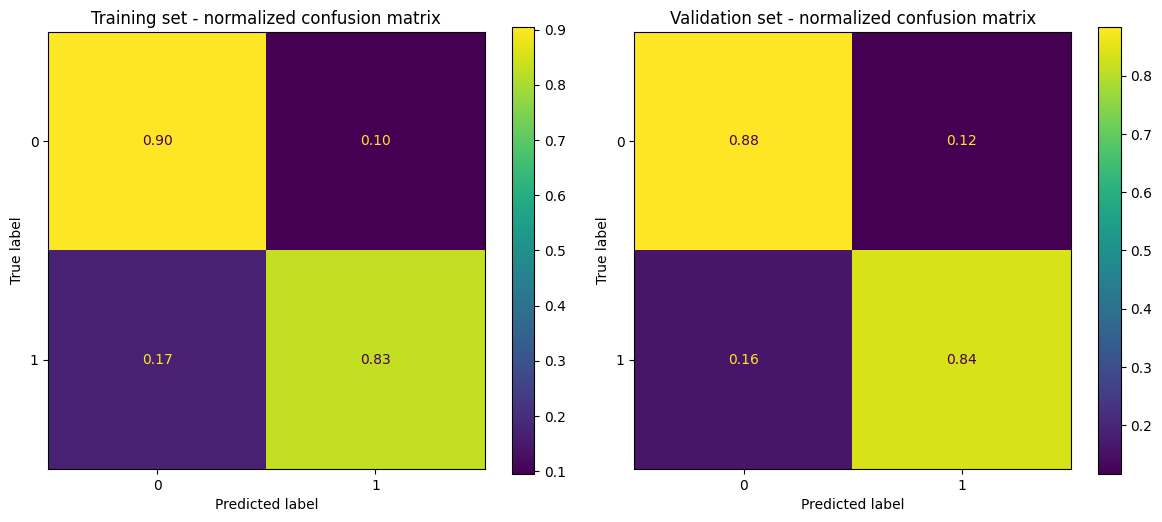

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_train_a0a1,
    normalize='true',
    values_format='.2f',
    ax=ax[0]
)
ax[0].set_title('Training set - normalized confusion matrix')

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred_valid_a0a1,
    normalize='true',
    values_format='.2f',
    ax=ax[1]
)
ax[1].set_title('Validation set - normalized confusion matrix')

plt.tight_layout()
plt.show()

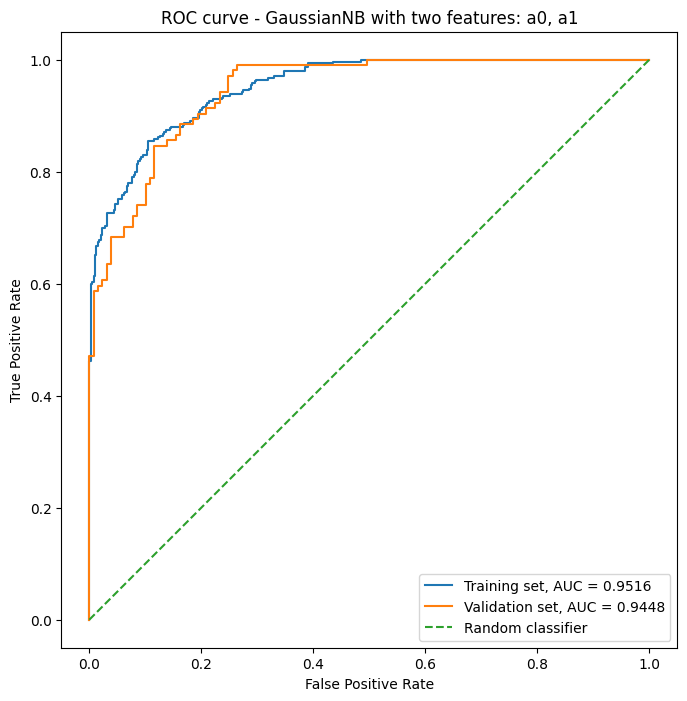

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    fprs_train_a0a1,
    tprs_train_a0a1,
    label=f'Training set, AUC = {auc_train_a0a1:.4f}'
)

ax.plot(
    fprs_valid_a0a1,
    tprs_valid_a0a1,
    label=f'Validation set, AUC = {auc_valid_a0a1:.4f}'
)

ax.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve - GaussianNB with two features: a0, a1')
ax.legend()
ax.set_aspect(1.0)

plt.show()

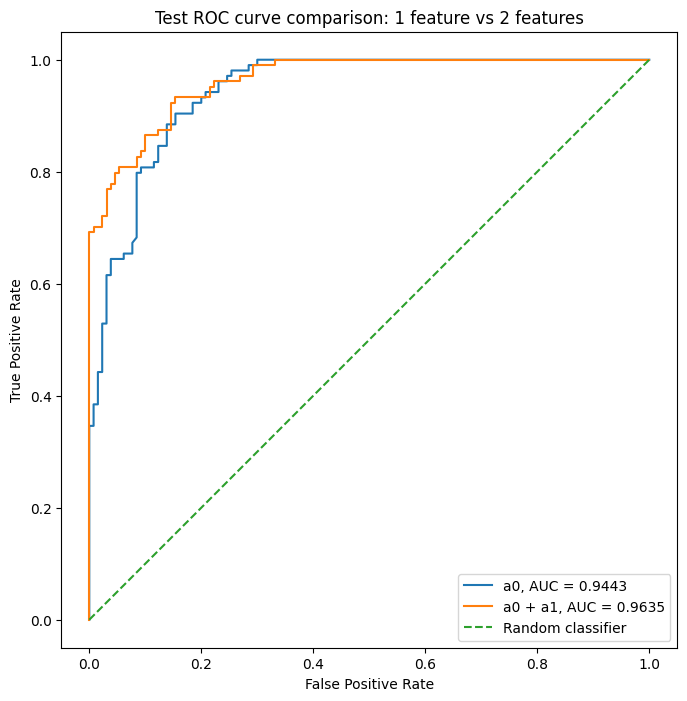

AUC improvement on the test set: 0.0192
AUC improvement in percentage points: 1.92 p.p.


In [23]:
auc_improvement_a0a1_over_a0 = auc_test_a0a1 - auc_test_a0

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    fprs_test_a0,
    tprs_test_a0,
    label=f'a0, AUC = {auc_test_a0:.4f}'
)

ax.plot(
    fprs_test_a0a1,
    tprs_test_a0a1,
    label=f'a0 + a1, AUC = {auc_test_a0a1:.4f}'
)

ax.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Test ROC curve comparison: 1 feature vs 2 features')
ax.legend()
ax.set_aspect(1.0)

plt.show()

print(f"AUC improvement on the test set: {auc_improvement_a0a1_over_a0:.4f}")
print(f"AUC improvement in percentage points: {100 * auc_improvement_a0a1_over_a0:.2f} p.p.")

## Problem 3

Same as Problem 2 but now implement Gaussian Naive Bayes using all features. Show confusion matrix only for test set. Compare all three ROC curves on the test set, same with AUC score.

In [24]:
gnb_all = GaussianNB()

gnb_all.fit(data_train_fit[features_all], y_train)

y_pred_test_all = gnb_all.predict(data_test[features_all])
y_score_test_all = gnb_all.predict_proba(data_test[features_all])[:, 1]

auc_test_all = roc_auc_score(y_test, y_score_test_all)

fprs_test_all, tprs_test_all, thresholds_test_all = roc_curve(
    y_test,
    y_score_test_all
)

print(f"Test ROC AUC for all-features classifier: {auc_test_all:.4f}")

Test ROC AUC for all-features classifier: 0.9521


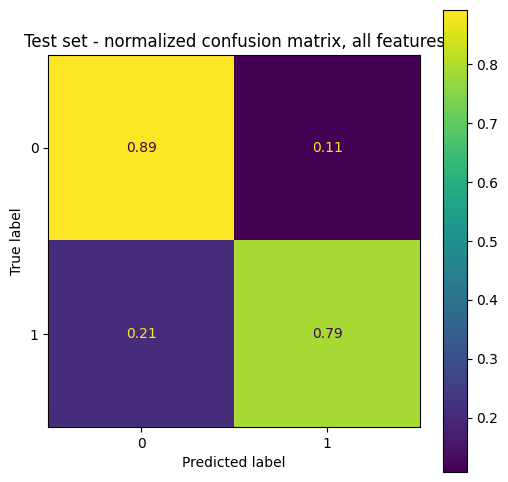

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_all,
    normalize='true',
    values_format='.2f',
    ax=ax
)

ax.set_title('Test set - normalized confusion matrix, all features')

plt.show()

In [26]:
auc_summary = pd.DataFrame({
    'classifier': ['a0', 'a0 + a1', 'all features'],
    'test_auc': [auc_test_a0, auc_test_a0a1, auc_test_all]
})

auc_summary

,classifier,test_auc
0,a0,0.944268
1,a0 + a1,0.963462
2,all features,0.952071


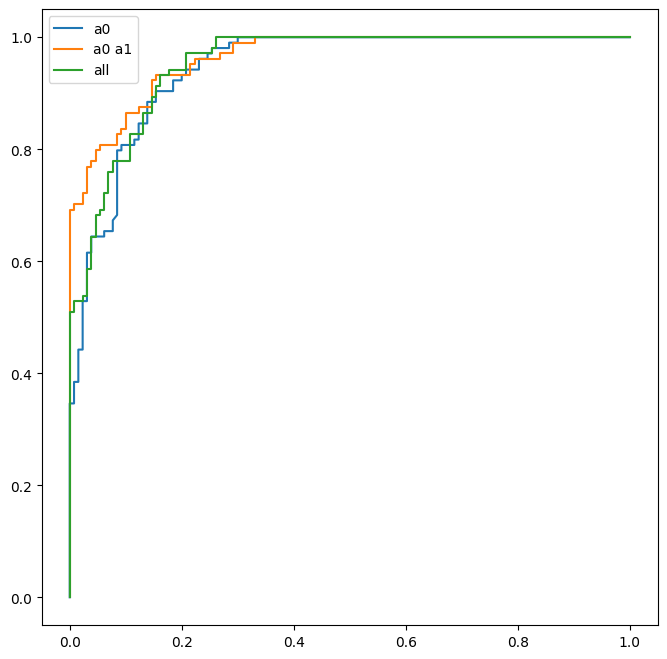

In [27]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect(1.0)
plt.plot(fprs_test_a0, tprs_test_a0,label='a0');
plt.plot(fprs_test_a0a1, tprs_test_a0a1,label='a0 a1');
plt.plot(fprs_test_all, tprs_test_all,label='all');
plt.legend();